In [1]:
import sys
sys.path.append(r"C:\Users\Akash\Desktop\stock-forecasting\src")

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from prophet import Prophet

from data_loader import load_all
from feature_engineering import add_features
from prophet_model import (
    prepare_prophet_data,
    train_test_split_prophet,
    build_and_train_prophet,
    forecast_and_evaluate
)

print("✓ All imports successful")

✓ All imports successful


In [2]:
data_raw = load_all(save=False)  # already saved in Phase 1
print("Loaded tickers:", list(data_raw.keys()))

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Loaded tickers: ['AAPL', 'RELIANCE.NS', 'INFY.NS']


In [3]:
ticker = "AAPL"
df = data_raw[ticker]

prophet_df         = prepare_prophet_data(df)
train, test        = train_test_split_prophet(prophet_df, test_ratio=0.2)
model              = build_and_train_prophet(train)
forecast, test_fc, metrics = forecast_and_evaluate(model, train, test)

print(f"\n📊 Prophet Metrics — {ticker}")
print(f"  MAE  : ${metrics['MAE']}")
print(f"  RMSE : ${metrics['RMSE']}")
print(f"  MAPE : {metrics['MAPE']}%")

Train: 1207 rows | Test: 302 rows
Train end : 2023-10-17
Test start: 2023-10-18


22:56:07 - cmdstanpy - INFO - Chain [1] start processing
22:56:08 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet Metrics — AAPL
  MAE  : $14.201
  RMSE : $18.2468
  MAPE : 7.6517%


In [4]:
def plot_prophet_forecast(train, test, test_fc, forecast, ticker):
    fig = go.Figure()

    # Training data
    fig.add_trace(go.Scatter(
        x=train["ds"], y=train["y"],
        name="Train", line=dict(color="#888", width=1)
    ))

    # Actual test prices
    fig.add_trace(go.Scatter(
        x=test["ds"], y=test["y"],
        name="Actual", line=dict(color="#2196F3", width=2)
    ))

    # Prophet forecast
    fig.add_trace(go.Scatter(
        x=test_fc["ds"], y=test_fc["yhat"],
        name="Forecast", line=dict(color="#FF9800", width=2)
    ))

    # Confidence interval band
    fig.add_trace(go.Scatter(
        x=pd.concat([test_fc["ds"], test_fc["ds"][::-1]]),
        y=pd.concat([test_fc["yhat_upper"], test_fc["yhat_lower"][::-1]]),
        fill="toself",
        fillcolor="rgba(255,152,0,0.15)",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI"
    ))

    fig.update_layout(
        title=f"{ticker} — Prophet Forecast vs Actual",
        xaxis_title="Date",
        yaxis_title="Price (USD)",
        height=500,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02)
    )
    fig.show()

plot_prophet_forecast(train, test, test_fc, forecast, ticker)

In [5]:
from prophet.plot import plot_components_plotly

fig = plot_components_plotly(model, forecast)
fig.update_layout(title=f"{ticker} — Prophet Components", template="plotly_white")
fig.show()

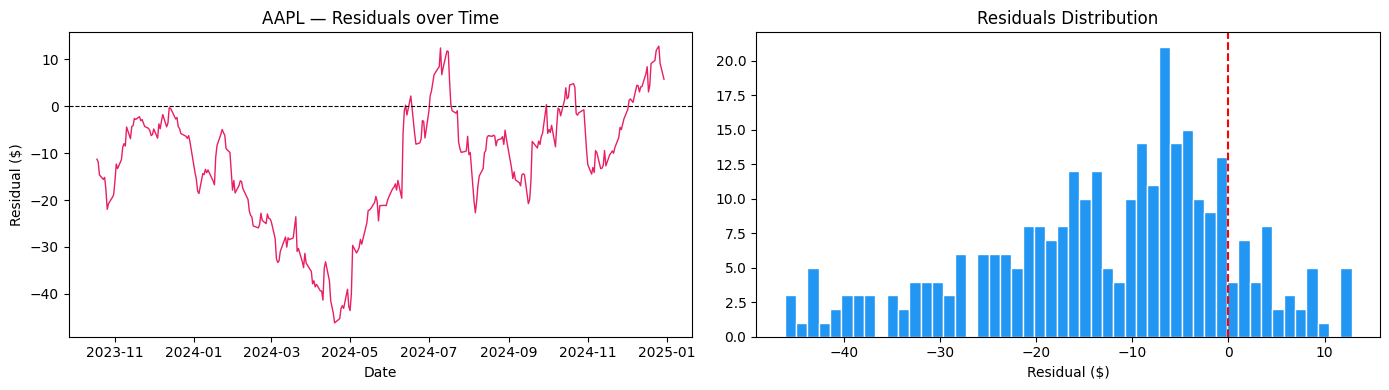

Mean residual : $-12.7639  (closer to 0 = less bias)
Std  residual : $13.0612


In [6]:
import matplotlib.pyplot as plt

test_copy = test.reset_index(drop=True).copy()
test_copy["residual"] = test_copy["y"] - test_fc["yhat"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals over time
axes[0].plot(test_copy["ds"], test_copy["residual"], color="#E91E63", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title(f"{ticker} — Residuals over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual ($)")

# Residuals distribution
axes[1].hist(test_copy["residual"], bins=50, color="#2196F3", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

print(f"Mean residual : ${test_copy['residual'].mean():.4f}  (closer to 0 = less bias)")
print(f"Std  residual : ${test_copy['residual'].std():.4f}")

In [8]:
import os

results = {}

for ticker, df in data_raw.items():
    print(f"\nTraining Prophet on {ticker}...")
    prophet_df  = prepare_prophet_data(df)
    train, test = train_test_split_prophet(prophet_df, test_ratio=0.2)
    model       = build_and_train_prophet(train)
    _, test_fc, metrics = forecast_and_evaluate(model, train, test)
    results[ticker] = metrics

# Summary table
summary = pd.DataFrame(results).T
summary.index.name = "Ticker"
print("\n====== Prophet Results Summary ======")
print(summary.to_string())
os.makedirs("data", exist_ok=True)
summary.to_csv("data/prophet_metrics.csv")
print("\nSaved to data/prophet_metrics.csv")


Training Prophet on AAPL...
Train: 1207 rows | Test: 302 rows
Train end : 2023-10-17
Test start: 2023-10-18


22:59:57 - cmdstanpy - INFO - Chain [1] start processing
22:59:57 - cmdstanpy - INFO - Chain [1] done processing
22:59:58 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet on RELIANCE.NS...
Train: 1184 rows | Test: 296 rows
Train end : 2023-10-13
Test start: 2023-10-16


22:59:58 - cmdstanpy - INFO - Chain [1] done processing
22:59:59 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet on INFY.NS...
Train: 1184 rows | Test: 296 rows
Train end : 2023-10-13
Test start: 2023-10-16


22:59:59 - cmdstanpy - INFO - Chain [1] done processing



====== Prophet Results Summary ======
                  MAE      RMSE     MAPE
Ticker                                  
AAPL          14.2010   18.2468   7.6517
RELIANCE.NS  179.6657  210.1086  12.5450
INFY.NS      299.7766  362.5843  17.6876

Saved to data/prophet_metrics.csv
